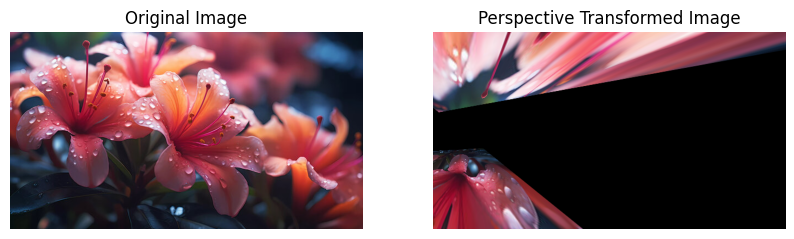

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
# Replace 'input_image.jpg' with the path to your image file.
# If running in Colab, you might need to upload the image file or provide a path to a file in Google Drive.
img = cv2.imread('Flower.jpg') # Changed from 'input_image.jpg' to 'Flower.jpg'

if img is None:
    print("Error: Image not found or could not be loaded.")
else:
    # Get image dimensions
    rows, cols, ch = img.shape

    # Define the 4 points on the original image that you want to transform
    # These should be the corners of the region you want to warp
    # Example: a rectangle (top-left, top-right, bottom-right, bottom-left)
    # You might need to adjust these points based on your specific image
    pts1 = np.float32([[50, 50], [200, 50], [50, 200], [200, 200]])

    # Define the 4 corresponding points on the output image
    # These points define where the original region will be mapped to
    # Example: a trapezoid (top-left, top-right, bottom-right, bottom-left)
    pts2 = np.float32([[10, 100], [200, 50], [100, 250], [10, 250]])

    # Get the perspective transformation matrix
    M = cv2.getPerspectiveTransform(pts1, pts2)

    # Apply the perspective transformation
    # The output image will have the same dimensions as the original image
    dst = cv2.warpPerspective(img, M, (cols, rows))

    # Display the original and transformed images using matplotlib
    plt.figure(figsize=(10, 5))

    plt.subplot(121)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(122)
    plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
    plt.title('Perspective Transformed Image')
    plt.axis('off')

    plt.show()

### Explanation of the Code:

1.  **Import Libraries**: `cv2` for OpenCV functions, `numpy` for array manipulation, and `matplotlib.pyplot` for displaying images.
2.  **Load Image**: `cv2.imread()` loads the image. **Remember to replace `'input_image.jpg'` with the actual path to your image.**
3.  **Define Source Points (`pts1`)**: These are 4 points (e.g., corners of a region) in the original image that you want to transform. They should be defined in a consistent order (e.g., top-left, top-right, bottom-right, bottom-left).
4.  **Define Destination Points (`pts2`)**: These are the 4 corresponding points in the output image where the `pts1` will be mapped. The arrangement of `pts2` determines the type of perspective distortion.
5.  **Get Transformation Matrix**: `cv2.getPerspectiveTransform(pts1, pts2)` calculates the 3x3 transformation matrix `M` that maps `pts1` to `pts2`.
6.  **Apply Transformation**: `cv2.warpPerspective(img, M, (cols, rows))` applies the calculated transformation matrix `M` to the original image `img`. The `(cols, rows)` argument specifies the size of the output image.
7.  **Display Images**: `matplotlib.pyplot` is used to display both the original and the transformed images side-by-side. `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` is used because OpenCV loads images in BGR format, but Matplotlib expects RGB.